In [1]:
#!pip install yfinance

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Pull Reliance data
ticker = yf.Ticker("RELIANCE.NS")

# Financials
income_stmt = ticker.financials          # P&L
balance_sheet = ticker.balance_sheet    # Balance sheet
cash_flow = ticker.cashflow             # Cash flow statement

print("Income Statement columns:", income_stmt.columns.tolist())
print("\nCash Flow columns:", cash_flow.columns.tolist())
print("\nBalance Sheet columns:", balance_sheet.columns.tolist())

Income Statement columns: [Timestamp('2026-03-31 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2023-03-31 00:00:00'), Timestamp('2022-03-31 00:00:00')]

Cash Flow columns: [Timestamp('2026-03-31 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2023-03-31 00:00:00'), Timestamp('2022-03-31 00:00:00')]

Balance Sheet columns: [Timestamp('2026-03-31 00:00:00'), Timestamp('2025-03-31 00:00:00'), Timestamp('2024-03-31 00:00:00'), Timestamp('2023-03-31 00:00:00'), Timestamp('2022-03-31 00:00:00')]


In [2]:
print("=== INCOME STATEMENT ===")
print(income_stmt.index.tolist())

print("\n=== CASH FLOW ===")
print(cash_flow.index.tolist())

print("\n=== BALANCE SHEET ===")
print(balance_sheet.index.tolist())

=== INCOME STATEMENT ===
['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Rent Expense Supplemental', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Net Income Common Stockholders', 'Otherunder Preferred Stock Dividend', 'Net Income', 'Minority Interests', 'Net Income Including Noncontrolling Interests', 'Net Income Discontinuous Operations', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Other Special Charges', 'Write Off', 'Net Non Operating Inter

In [5]:
latest = income_stmt.columns[0]  # FY2026

# Income Statement
revenue = income_stmt.loc['Total Revenue']
ebit = income_stmt.loc['EBIT']
tax_rate = income_stmt.loc['Tax Rate For Calcs']
depreciation = income_stmt.loc['Reconciled Depreciation']

# Cash Flow
capex = cash_flow.loc['Capital Expenditure']  
operating_cf = cash_flow.loc['Operating Cash Flow']
free_cash_flow = cash_flow.loc['Free Cash Flow']

# Balance Sheet
total_debt = balance_sheet.loc['Total Debt']
cash = balance_sheet.loc['Cash And Cash Equivalents']
shares_outstanding = balance_sheet.loc['Ordinary Shares Number']

print("=== KEY FINANCIALS (INR Crores) ===\n")
print("REVENUE:")
print((revenue / 1e7).round(0))

print("\nEBIT:")
print((ebit / 1e7).round(0))

print("\nTAX RATE:")
print(tax_rate.round(3))

print("\nDEPRECIATION:")
print((depreciation / 1e7).round(0))

print("\nCAPEX:")
print((capex / 1e7).round(0))

print("\nFREE CASH FLOW:")
print((free_cash_flow / 1e7).round(0))

print("\nTOTAL DEBT (latest year):", round(total_debt.iloc[0] / 1e7, 0), "Cr")
print("CASH (latest year):", round(cash.iloc[0] / 1e7, 0), "Cr")
print("SHARES OUTSTANDING:", round(shares_outstanding.iloc[0] / 1e7, 2), "Cr shares")

=== KEY FINANCIALS (INR Crores) ===

REVENUE:
2026-03-31    1057219.0
2025-03-31     964693.0
2024-03-31     901064.0
2023-03-31     877835.0
2022-03-31          NaN
Name: Total Revenue, dtype: float64

EBIT:
2026-03-31    147218.0
2025-03-31    128138.0
2024-03-31    126112.0
2023-03-31    113004.0
2022-03-31         NaN
Name: EBIT, dtype: float64

TAX RATE:
2026-03-31    0.224
2025-03-31    0.238
2024-03-31    0.246
2023-03-31    0.218
2022-03-31      NaN
Name: Tax Rate For Calcs, dtype: float64

DEPRECIATION:
2026-03-31    57688.0
2025-03-31    53136.0
2024-03-31    50832.0
2023-03-31    40303.0
2022-03-31        NaN
Name: Reconciled Depreciation, dtype: float64

CAPEX:
2026-03-31   -122916.0
2025-03-31   -139967.0
2024-03-31   -152883.0
2023-03-31   -140988.0
2022-03-31         NaN
Name: Capital Expenditure, dtype: float64

FREE CASH FLOW:
2026-03-31    69197.0
2025-03-31    38736.0
2024-03-31     5905.0
2023-03-31   -25956.0
2022-03-31        NaN
Name: Free Cash Flow, dtype: float

EBIT = EARNINGS BEFORE INTEREST AND TAXES

DEP_PCT_REVENUE = DEPRECIATION AS % OF REVENUE 

CAPEX_PCT_REVENUE = CAPITAL EXPENDITURE AS % OF REVENUE

WACC = AVERAGE COST A COMPANY INCURS TO FINANCE ITS OPERATIONS

NOPAT = NET OPERATING PROFIT AFTER TAX 

D&A= DEPRECIATION AND AMORTIZATION

FCFF = FREE CASH FLOW TO THE FIRM 

Revenue = last year's revenue × (1 + growth rate)

EBIT = Revenue × EBIT margin

NOPAT = EBIT × (1 - tax rate) → operating profit after tax, ignoring debt

FCFF = NOPAT + Depreciation - Capex → the actual cash the business generates for all investors

In [7]:
#DCF MODEL

revenue_growth_rates = [0.10, 0.10, 0.09, 0.08, 0.08]  # YoY revenue growth FY27-FY31
ebit_margin = 0.139        # EBIT / Revenue (avg of last 3 years)
tax_rate = 0.235           # avg tax rate
dep_pct_revenue = 0.054    # Depreciation as % of revenue
capex_pct_revenue = 0.085  # Capex as % of revenue (declining trend)
wacc = 0.10                # Weighted Average Cost of Capital
terminal_growth = 0.045    # Long-term growth rate (India nominal GDP ~7%, conservative)

# === BASE YEAR (FY2026) ===
base_revenue = 1057219     # Cr
net_debt = 398000 - 137327 # Total Debt - Cash
shares = 1353.25           # Cr shares

# === PROJECT 5 YEARS OF FCF ===
projected = []
rev = base_revenue

print(f"{'Year':<8} {'Revenue':>12} {'EBIT':>12} {'NOPAT':>12} {'D&A':>10} {'Capex':>12} {'FCFF':>12}")
print("-" * 80)

# i=index(0,1,2,3,4)
# g=growth rate
for i, g in enumerate(revenue_growth_rates):
    year = f"FY{27+i}"
    rev = rev * (1 + g)
    ebit = rev * ebit_margin
    nopat = ebit * (1 - tax_rate)          # Net Operating Profit After Tax
    dep = rev * dep_pct_revenue
    capex = rev * capex_pct_revenue
    fcff = nopat + dep - capex             # Free Cash Flow to Firm
    projected.append(fcff)                 # saves each year's FCFF into a list
    print(f"{year:<8} {rev:>12,.0f} {ebit:>12,.0f} {nopat:>12,.0f} {dep:>10,.0f} {capex:>12,.0f} {fcff:>12,.0f}")

# === TERMINAL VALUE === 
terminal_fcff = projected[-1] * (1 + terminal_growth) # FY31's FCFF grown by one more year 
terminal_value = terminal_fcff / (wacc - terminal_growth)
#Terminal value is the estimated value of a company or asset at a future point in time,
# assuming it will grow at a stable rate indefinitely.
#terminal value=worth today of everything Reliance earns from FY32 to infinity

# === DISCOUNT EVERYTHING BACK ===
discount_factors = [(1 / (1 + wacc)**i) for i in range(1, 6)]
# discount factor= present value of a future cash flow
pv_fcffs = [fcff * df for fcff, df in zip(projected, discount_factors)]
# each year's cash flow is worth in today's money
pv_terminal = terminal_value * discount_factors[-1]
#

# === ENTERPRISE & EQUITY VALUE ===
enterprise_value = sum(pv_fcffs) + pv_terminal
equity_value = enterprise_value - net_debt
intrinsic_price = equity_value / shares

print(f"\n=== DCF VALUATION SUMMARY ===")
print(f"PV of FCFFs (FY27-31):     ₹{sum(pv_fcffs):>10,.0f} Cr")
print(f"PV of Terminal Value:       ₹{pv_terminal:>10,.0f} Cr")
print(f"Enterprise Value:           ₹{enterprise_value:>10,.0f} Cr")
print(f"Less: Net Debt:             ₹{net_debt:>10,.0f} Cr")
print(f"Equity Value:               ₹{equity_value:>10,.0f} Cr")
print(f"Shares Outstanding:         {shares:>10,.2f} Cr")
print(f"\nIntrinsic Value per Share:  ₹{intrinsic_price:>10,.2f}")

Year          Revenue         EBIT        NOPAT        D&A        Capex         FCFF
--------------------------------------------------------------------------------
FY27        1,162,941      161,649      123,661     62,799       98,850       87,610
FY28        1,279,235      177,814      136,027     69,079      108,735       96,371
FY29        1,394,366      193,817      148,270     75,296      118,521      105,045
FY30        1,505,915      209,322      160,132     81,319      128,003      113,448
FY31        1,626,389      226,068      172,942     87,825      138,243      122,524

=== DCF VALUATION SUMMARY ===
PV of FCFFs (FY27-31):     ₹   391,777 Cr
PV of Terminal Value:       ₹ 1,445,477 Cr
Enterprise Value:           ₹ 1,837,254 Cr
Less: Net Debt:             ₹   260,673 Cr
Equity Value:               ₹ 1,576,581 Cr
Shares Outstanding:           1,353.25 Cr

Intrinsic Value per Share:  ₹  1,165.03


### GORDON GROWTH MODEL
Calculates for future cash flows are worth now

Value = Next year's cash flow/ Discount rate - Growth rate
##### Terminal Value = FCFF*(1+g) / (WACC-g)

In [13]:
current_price = ticker.info['currentPrice']
print(f"Current Market Price: ₹{current_price:,.2f}")
print(f"Intrinsic Value:      ₹268.70")
print(f"Upside/Downside:      {((268.70 - current_price) / current_price * 100):.1f}%")

Current Market Price: ₹1,316.50
Intrinsic Value:      ₹268.70
Upside/Downside:      -79.6%


In [8]:
#Sensitivity Analysis
import numpy as np
import pandas as pd

wacc_range = [0.09, 0.10, 0.11, 0.12, 0.13]
tg_range = [0.030, 0.035, 0.040, 0.045, 0.050]

table = []
for w in wacc_range:
    row = []
    for g in tg_range:
        tv = projected[-1] * (1 + g) / (w - g)
        dfs = [(1 / (1 + w)**i) for i in range(1, 6)]
        pv_f = sum([f * d for f, d in zip(projected, dfs)])
        pv_t = tv * dfs[-1]
        ev = pv_f + pv_t
        eq = ev - net_debt
        price = eq / shares
        row.append(round(price, 0))
    table.append(row)

df_sensitivity = pd.DataFrame(
    table,
    index=[f"WACC={int(w*100)}%" for w in wacc_range],
    columns=[f"g={int(g*100)}%" for g in tg_range]
)

# Color code: green = undervalued vs market, red = overvalued
current = 1316.50

def color(val):
    if val < current * 0.90:
        return 'background-color: #c6efce; color: #276221'  # green
    elif val > current * 1.10:
        return 'background-color: #ffc7ce; color: #9c0006'  # red
    else:
        return 'background-color: #ffeb9c; color: #9c5700'  # yellow = fairly valued

print(f"Current Market Price: ₹{current}\n")
df_sensitivity

Current Market Price: ₹1316.5



,g=3%,g=3%,g=4%,g=4%,g=5%
WACC=9%,1115.0,1212.0,1329.0,1471.0,1650.0
WACC=10%,924.0,992.0,1071.0,1165.0,1277.0
WACC=11%,781.0,831.0,888.0,953.0,1030.0
WACC=12%,670.0,707.0,750.0,798.0,852.0
WACC=13%,581.0,610.0,643.0,679.0,720.0


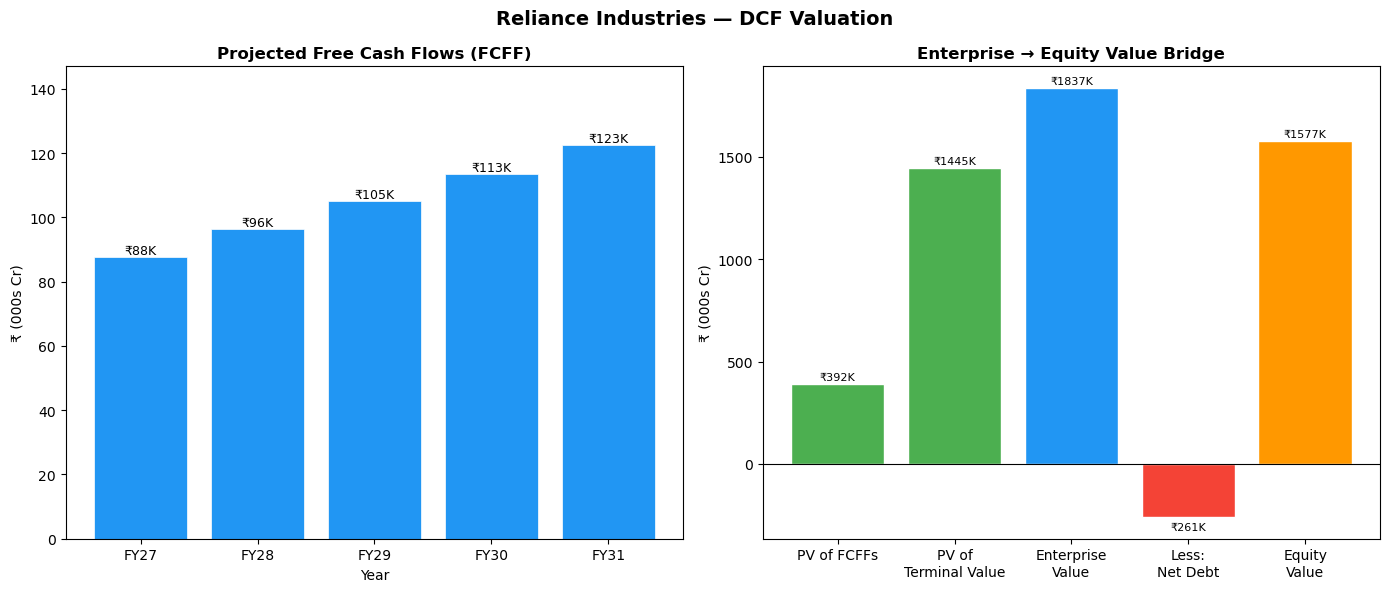

Chart saved as reliance_dcf.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Reliance Industries — DCF Valuation', fontsize=14, fontweight='bold')

# --- Chart 1: Projected FCFFs ---
years = ['FY27', 'FY28', 'FY29', 'FY30', 'FY31']
colors = ['#2196F3'] * 5
axes[0].bar(years, [p/1000 for p in projected], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Projected Free Cash Flows (FCFF)', fontweight='bold')
axes[0].set_ylabel('₹ (000s Cr)')
axes[0].set_xlabel('Year')
for i, v in enumerate(projected):
    axes[0].text(i, v/1000 + 1, f'₹{v/1000:.0f}K', ha='center', fontsize=9)
axes[0].set_ylim(0, max(projected)/1000 * 1.2)

# --- Chart 2: Value Bridge ---
labels = ['PV of FCFFs', 'PV of\nTerminal Value', 'Enterprise\nValue', 'Less:\nNet Debt', 'Equity\nValue']
values = [391777, 1445477, 1837254, -260673, 1576581]
bar_colors = ['#4CAF50', '#4CAF50', '#2196F3', '#F44336', '#FF9800']
axes[1].bar(labels, [v/1000 for v in values], color=bar_colors, edgecolor='white')
axes[1].set_title('Enterprise → Equity Value Bridge', fontweight='bold')
axes[1].set_ylabel('₹ (000s Cr)')
axes[1].axhline(y=0, color='black', linewidth=0.8)
for i, v in enumerate(values):
    ypos = v/1000 + 20 if v > 0 else v/1000 - 60
    axes[1].text(i, ypos, f'₹{abs(v)/1000:.0f}K', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('reliance_dcf.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as reliance_dcf.png")